In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
train = pd.read_csv(r"C:\Users\Aditya P J\Documents\Competition\Kaggle\Predict Costumer Churn\Data\train.csv")
test = pd.read_csv(r"C:\Users\Aditya P J\Documents\Competition\Kaggle\Predict Costumer Churn\Data\test.csv")
train.head(20)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
5,5,Male,0,Yes,Yes,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.20,No
6,6,Female,0,Yes,Yes,24,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,533.60,No
7,7,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Electronic check,92.00,6827.50,No
8,8,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,79.55,79.55,Yes
9,9,Male,0,No,No,55,Yes,No,Fiber optic,Yes,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.05,4738.30,No


## Explorasi Data Analis

In [4]:
train.info()

"""
1. Kolom gender ubah format menjadi Male = 0, dan Female = 1
2. SeniorCitizen adalah orang lanjut usia atau tidak jika iya =1, tidal =0
3. Partner adalah informasi mengenai orang tersebut sudah menikah atau belum, lalu ubah format menjadi angka biner, bila iya = 1, tidak = 0
4. Dependens apakah orang tersebut memiliki tanggungan ubah menjadi 1 dan 0
5. Tenure seberapa lama seorang pelanggan telah berlangganan atau menggunakan layanan perusahaan dalam bulan
6. Apakah pelanggan memiliki layanan telepon ubah menjadi biner
7. Apakah pelanggan memiliki beberapa saluran telepon jika poin 6 tidak otomatis poin 7 tidak, cek lagi
8. Internet service jenis internet yang dimiliki
9. Online Security Layanan keamanan daring (Yes, No, No internet service).
10.  OnlineBackup: Layanan pencadangan data daring.
11. DeviceProtection: Layanan perlindungan perangkat (asuransi perangkat).
12. TechSupport: Layanan dukungan teknis khusus (sering kali krusial bagi kelompok Senior Citizen).
13. StreamingTV & StreamingMovies: Apakah pelanggan menggunakan koneksi internet mereka untuk layanan streaming konten video.
14. Contract: Jenis kontrak pelanggan. Biasanya terdiri dari Month-to-month (bulanan), One year (1 tahun), atau Two year (2 tahun). Pelanggan bulanan biasanya paling berisiko untuk churn.
15. PaperlessBilling: Apakah tagihan dikirim secara digital/tanpa kertas (Yes/No).
16. PaymentMethod: Metode pembayaran yang digunakan (misalnya: Electronic check, Mailed check, Bank transfer, atau Credit card).
17. MonthlyCharges: Jumlah biaya yang ditagihkan kepada pelanggan setiap bulan.
18. TotalCharges: Total biaya yang telah dibayarkan pelanggan selama masa berlangganan (akumulasi).
"""

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

'\n1. Kolom gender ubah format menjadi Male = 0, dan Female = 1\n2. SeniorCitizen adalah orang lanjut usia atau tidak jika iya =1, tidal =0\n3. Partner adalah informasi mengenai orang tersebut sudah menikah atau belum, lalu ubah format menjadi angka biner, bila iya = 1, tidak = 0\n4. Dependens apakah orang tersebut memiliki tanggungan ubah menjadi 1 dan 0\n5. Tenure seberapa lama seorang pelanggan telah berlangganan atau menggunakan layanan perusahaan dalam bulan\n6. Apakah pelanggan memiliki layanan telepon ubah menjadi biner\n7. Apakah pelanggan memiliki beberapa saluran telepon jika poin 6 tidak otomatis poin 7 tidak, cek lagi\n8. Internet service jenis internet yang dimiliki\n9. Online Security Layanan keamanan daring (Yes, No, No internet service).\n10.  OnlineBackup: Layanan pencadangan data daring.\n11. DeviceProtection: Layanan perlindungan perangkat (asuransi perangkat).\n12. TechSupport: Layanan dukungan teknis khusus (sering kali krusial bagi kelompok Senior Citizen).\n13. S

In [5]:
train.describe(include='all')

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,594194.000000,594194,594194.000000,594194,594194,594194.000000,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194.000000,594194.000000,594194
unique,NaN,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,NaN,Female,NaN,Yes,No,NaN,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,NaN,298738,NaN,309554,414362,NaN,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,NaN,NaN,460377
mean,297096.500000,NaN,0.114102,NaN,NaN,36.577258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.866223,2494.377057,NaN
std,171529.177262,NaN,0.317936,NaN,NaN,25.061922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.067444,2353.916710,NaN
min,0.000000,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,148548.250000,NaN,0.000000,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.900000,639.650000,NaN
50%,297096.500000,NaN,0.000000,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.100000,1433.650000,NaN
75%,445644.750000,NaN,0.000000,NaN,NaN,62.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.800000,4263.800000,NaN


In [6]:
missing_values = train.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

## Bersih Bersih dan Transformasi Data

In [8]:
train = train.replace({'Yes':1, 'No':0})
train['gender'] = train['gender'].map({'Female':0, 'Male':0})
train.info()

C:\Users\Aditya P J\AppData\Local\Temp\ipykernel_12692\1501956627.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train = train.replace({'Yes':1, 'No':0})


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  int64  
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  int64  
 4   Dependents        594194 non-null  int64  
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  int64  
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [9]:
test = test.replace({'Yes':1, 'No':0})
test['gender'] = test['gender'].map({'Female':0, 'Male':1})
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  int64  
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  int64  
 4   Dependents        254655 non-null  int64  
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  int64  
 7   MultipleLines     254655 non-null  object 
 8   InternetService   254655 non-null  object 
 9   OnlineSecurity    254655 non-null  object 
 10  OnlineBackup      254655 non-null  object 
 11  DeviceProtection  254655 non-null  object 
 12  TechSupport       254655 non-null  object 
 13  StreamingTV       254655 non-null  object 
 14  StreamingMovies   254655 non-null  object 
 15  Contract          254655 non-null  object 
 16  PaperlessBilling  25

C:\Users\Aditya P J\AppData\Local\Temp\ipykernel_12692\1530621297.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test = test.replace({'Yes':1, 'No':0})


In [10]:
train = pd.get_dummies(train, columns=[
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
])  
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 42 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   id                                       594194 non-null  int64  
 1   gender                                   594194 non-null  int64  
 2   SeniorCitizen                            594194 non-null  int64  
 3   Partner                                  594194 non-null  int64  
 4   Dependents                               594194 non-null  int64  
 5   tenure                                   594194 non-null  int64  
 6   PhoneService                             594194 non-null  int64  
 7   PaperlessBilling                         594194 non-null  int64  
 8   MonthlyCharges                           594194 non-null  float64
 9   TotalCharges                             594194 non-null  float64
 10  Churn                           

In [11]:
test = pd.get_dummies(test, columns=[
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
])  
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 41 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   id                                       254655 non-null  int64  
 1   gender                                   254655 non-null  int64  
 2   SeniorCitizen                            254655 non-null  int64  
 3   Partner                                  254655 non-null  int64  
 4   Dependents                               254655 non-null  int64  
 5   tenure                                   254655 non-null  int64  
 6   PhoneService                             254655 non-null  int64  
 7   PaperlessBilling                         254655 non-null  int64  
 8   MonthlyCharges                           254655 non-null  float64
 9   TotalCharges                             254655 non-null  float64
 10  MultipleLines_0                 

In [12]:
bool_cols = train.select_dtypes('bool').columns
train[bool_cols] = train[bool_cols].astype(int)

In [13]:
bool_cols = test.select_dtypes('bool').columns
test[bool_cols] = test[bool_cols].astype(int)

## Outlier?

In [15]:
train.describe(include='all')

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_0,MultipleLines_1,MultipleLines_No phone service,InternetService_0,InternetService_DSL,InternetService_Fiber optic,OnlineSecurity_0,OnlineSecurity_1,OnlineSecurity_No internet service,OnlineBackup_0,OnlineBackup_1,OnlineBackup_No internet service,DeviceProtection_0,DeviceProtection_1,DeviceProtection_No internet service,TechSupport_0,TechSupport_1,TechSupport_No internet service,StreamingTV_0,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_0,StreamingMovies_1,StreamingMovies_No internet service,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,594194.000000,594194.0,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.0,0.114102,0.520965,0.302649,36.577258,0.938907,0.615252,65.866223,2494.377057,0.225208,0.476922,0.461985,0.061093,0.236837,0.304751,0.458413,0.487171,0.275992,0.236837,0.420878,0.342286,0.236837,0.416324,0.346840,0.236837,0.485651,0.277512,0.236837,0.358748,0.404415,0.236837,0.356840,0.406324,0.236837,0.503065,0.182319,0.314616,0.204243,0.225019,0.362461,0.208277
std,171529.177262,0.0,0.317936,0.499561,0.459405,25.061922,0.239501,0.486536,31.067444,2353.916710,0.417719,0.499468,0.498553,0.239501,0.425142,0.460302,0.498268,0.499836,0.447013,0.425142,0.493700,0.474475,0.425142,0.492949,0.475965,0.425142,0.499794,0.447772,0.425142,0.479634,0.490779,0.425142,0.479067,0.491147,0.425142,0.499991,0.386108,0.464363,0.403148,0.417595,0.480711,0.406076
min,0.000000,0.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,148548.250000,0.0,0.000000,0.000000,0.000000,12.000000,1.000000,0.000000,29.900000,639.650000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,297096.500000,0.0,0.000000,1.000000,0.000000,35.000000,1.000000,1.000000,74.100000,1433.650000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,445644.750000,0.0,0.000000,1.000000,1.000000,62.000000,1.000000,1.000000,90.800000,4263.800000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,594193.000000,0.0,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000

In [16]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_0,MultipleLines_1,MultipleLines_No phone service,InternetService_0,InternetService_DSL,InternetService_Fiber optic,OnlineSecurity_0,OnlineSecurity_1,OnlineSecurity_No internet service,OnlineBackup_0,OnlineBackup_1,OnlineBackup_No internet service,DeviceProtection_0,DeviceProtection_1,DeviceProtection_No internet service,TechSupport_0,TechSupport_1,TechSupport_No internet service,StreamingTV_0,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_0,StreamingMovies_1,StreamingMovies_No internet service,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,1,1,29,1,1,60.10,1653.85,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1
1,1,0,0,1,1,58,1,0,69.50,3778.20,0,1,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,1,0,0
2,2,0,0,1,0,58,1,1,100.40,5841.35,0,0,1,0,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0
3,3,0,0,0,0,1,1,1,69.70,70.70,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
4,4,0,0,0,0,1,1,1,70.45,70.45,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0


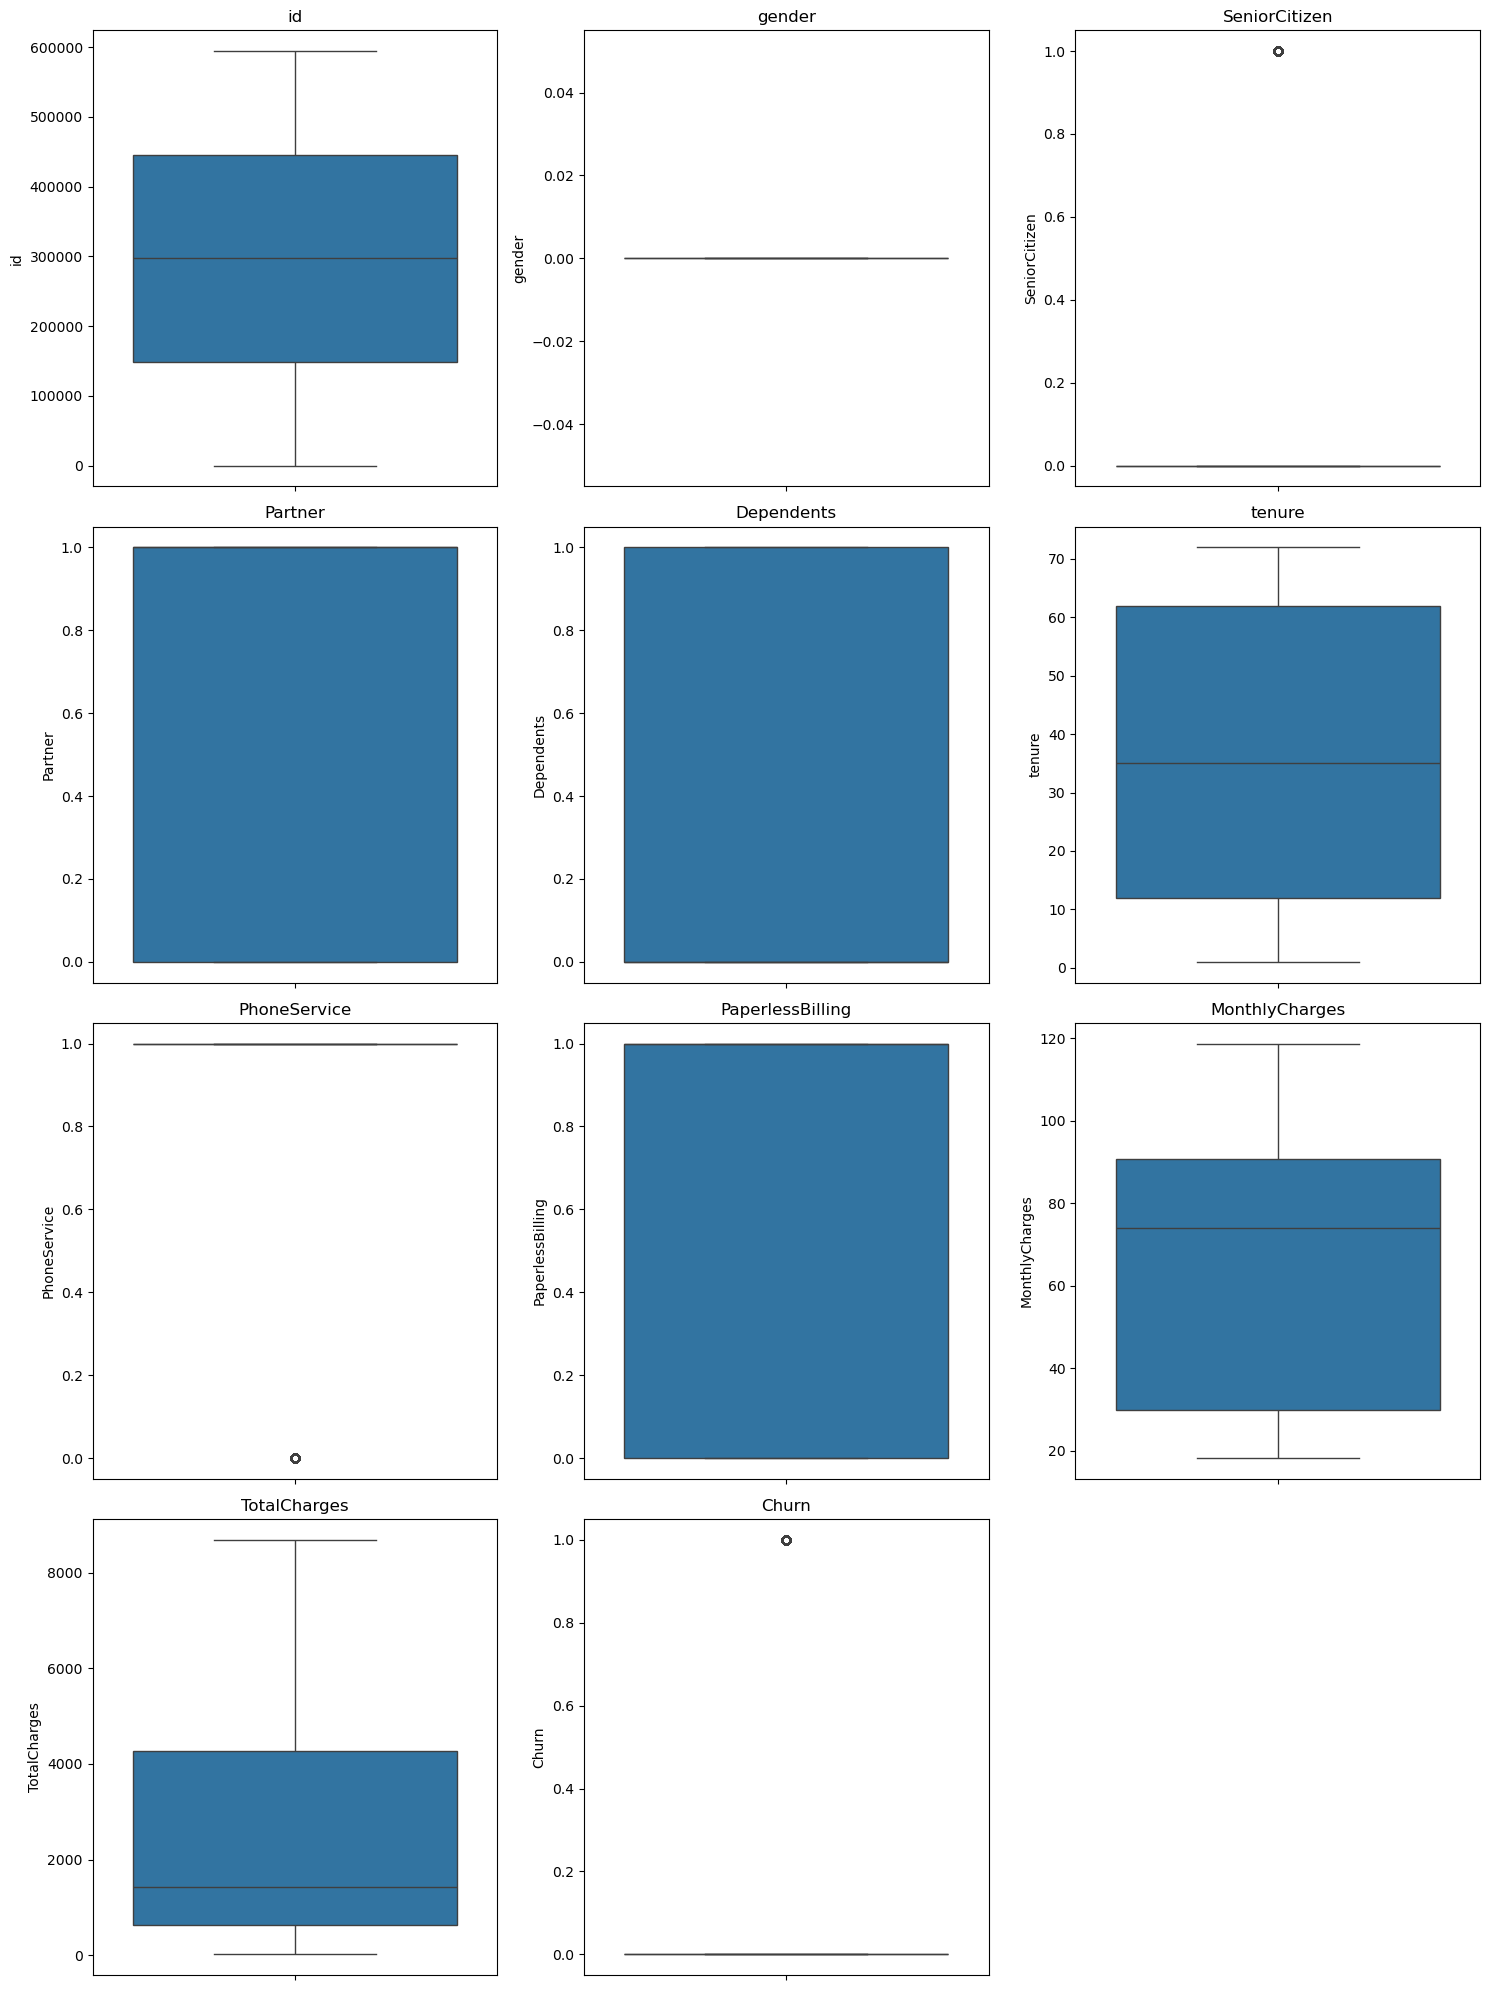

In [17]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 20))
for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols)//3 + 1, 3, i+1)
    sns.boxplot(y=train[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [18]:
duplicates = train.duplicated()

print('Baris duplikat:')
print(train[duplicates])

Baris duplikat:
Empty DataFrame
Columns: [id, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, PaperlessBilling, MonthlyCharges, TotalCharges, Churn, MultipleLines_0, MultipleLines_1, MultipleLines_No phone service, InternetService_0, InternetService_DSL, InternetService_Fiber optic, OnlineSecurity_0, OnlineSecurity_1, OnlineSecurity_No internet service, OnlineBackup_0, OnlineBackup_1, OnlineBackup_No internet service, DeviceProtection_0, DeviceProtection_1, DeviceProtection_No internet service, TechSupport_0, TechSupport_1, TechSupport_No internet service, StreamingTV_0, StreamingTV_1, StreamingTV_No internet service, StreamingMovies_0, StreamingMovies_1, StreamingMovies_No internet service, Contract_Month-to-month, Contract_One year, Contract_Two year, PaymentMethod_Bank transfer (automatic), PaymentMethod_Credit card (automatic), PaymentMethod_Electronic check, PaymentMethod_Mailed check]
Index: []


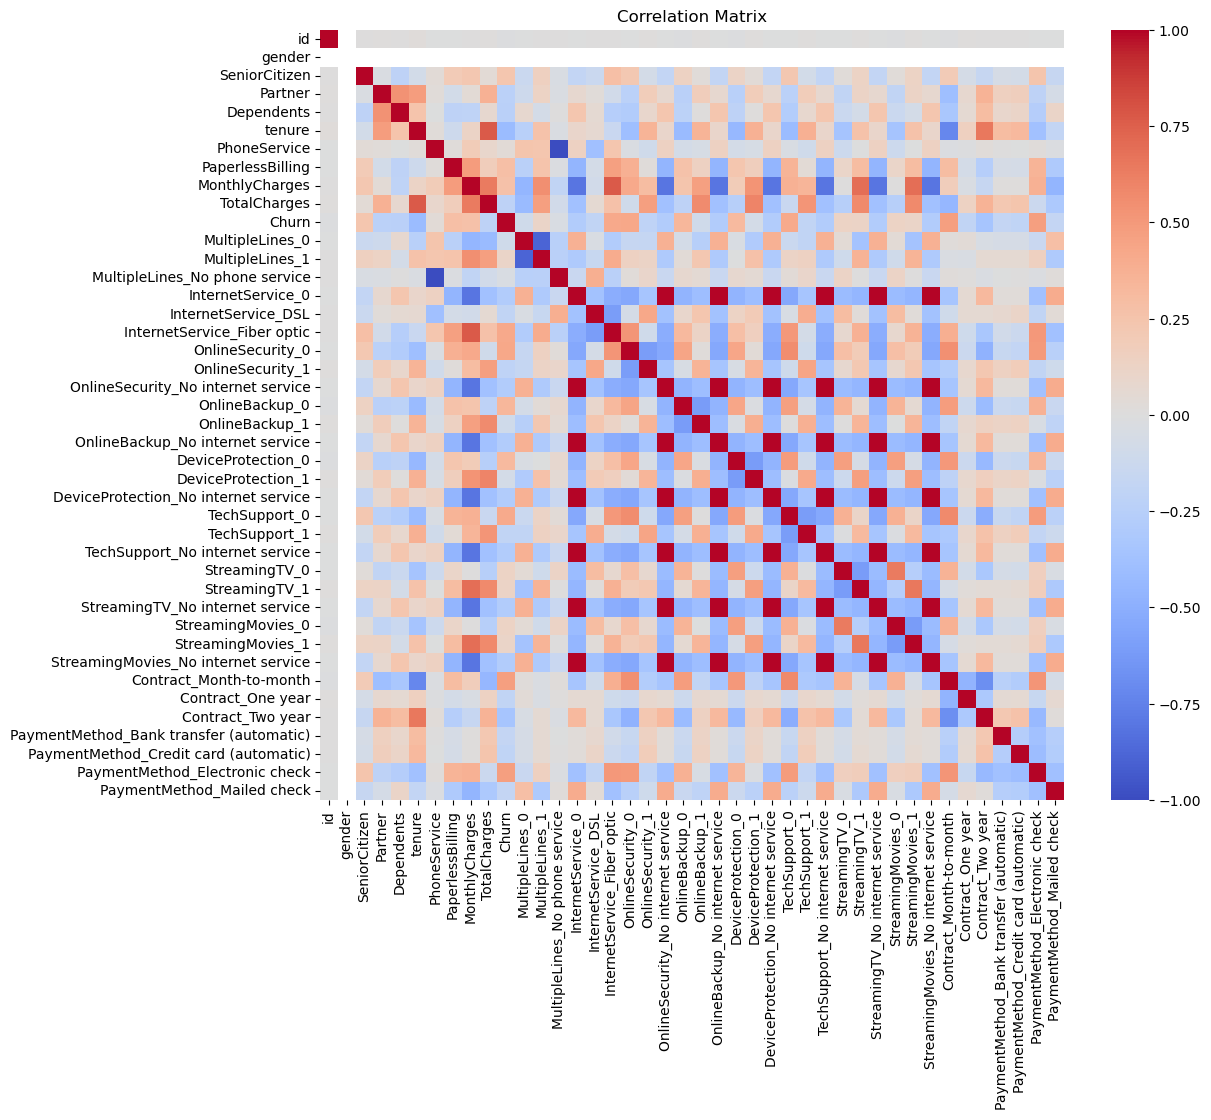

In [19]:
# Visualisasi korelasi antar variabel numerik
plt.figure(figsize=(12, 10))
correlation_matrix = train.corr()
 
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

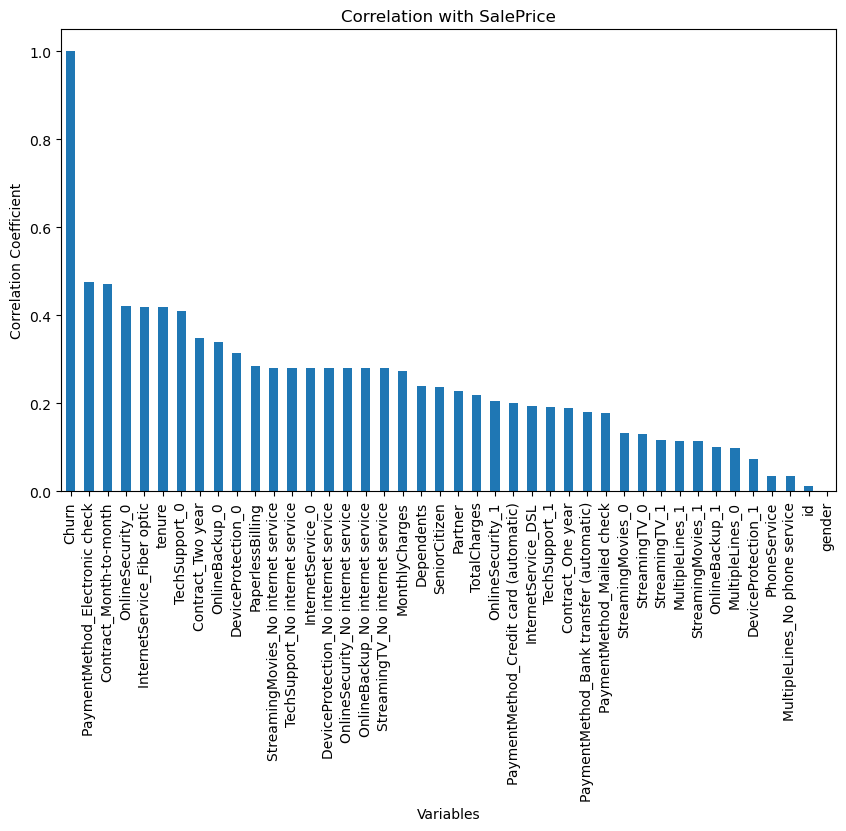

In [20]:
# Menghitung korelasi antara variabel target dan semua variabel lainnya
target_corr = train.corr()['Churn']
 
# (Opsional) Mengurutkan hasil korelasi berdasarkan korelasi
target_corr_sorted = target_corr.abs().sort_values(ascending=False)
 
plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with SalePrice')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

In [21]:
train = train.drop(['gender'], axis=1)

## Data Splitting

In [23]:
import sklearn
from sklearn.model_selection import train_test_split

In [24]:
#Memisahkan fitur (X) dan target (y)
X = train.drop(columns=['Churn'])
y = train['Churn']

In [25]:
x_train, x_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=1,
    stratify=y
)

In [26]:
print('Jumlah data: ',len(X))
print('Jumlah data latih: ',len(x_train))
print('Jumlah data test: ',len(x_test))

Jumlah data:  594194
Jumlah data latih:  475355
Jumlah data test:  118839


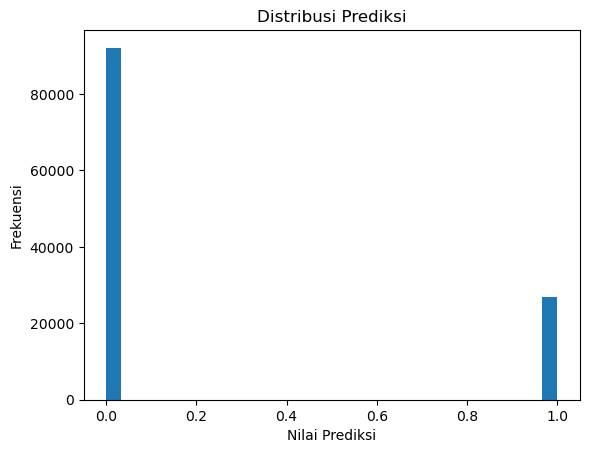

In [27]:
import matplotlib.pyplot as plt

plt.hist(y_test, bins=30)
plt.title("Distribusi Prediksi")
plt.xlabel("Nilai Prediksi")
plt.ylabel("Frekuensi")
plt.show()

## Modeling

In [86]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = round(neg / pos, 2)
print(f"\nscale_pos_weight = {neg} / {pos} = {spw}")


scale_pos_weight = 368301 / 107054 = 3.44


In [96]:
#XGBoost
from sklearn.metrics import accuracy_score, classification_report, f1_score, average_precision_score
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    n_estimators=800,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,   # ← kunci class imbalance
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20
)
 
xgb.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    verbose=50
)

y_prob = xgb.predict_proba(x_test)[:, 1]
y_pred_default = xgb.predict(x_test)
 
print("\n" + "="*55)
print("HASIL — Threshold Default (0.5)")
print("="*55)
print(f"Accuracy : {accuracy_score(y_test, y_pred_default):.4f}")
print(f"F1 Kelas 1: {f1_score(y_test, y_pred_default):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred_default))

[0]	validation_0-logloss:0.66874
[50]	validation_0-logloss:0.39298
[100]	validation_0-logloss:0.38016
[150]	validation_0-logloss:0.37756
[200]	validation_0-logloss:0.37597
[250]	validation_0-logloss:0.37475
[300]	validation_0-logloss:0.37402
[350]	validation_0-logloss:0.37337
[400]	validation_0-logloss:0.37273
[450]	validation_0-logloss:0.37226
[500]	validation_0-logloss:0.37182
[550]	validation_0-logloss:0.37130
[600]	validation_0-logloss:0.37096
[650]	validation_0-logloss:0.37057
[700]	validation_0-logloss:0.37034
[727]	validation_0-logloss:0.37027

HASIL — Threshold Default (0.5)
Accuracy : 0.8205
F1 Kelas 1: 0.6869
PR-AUC   : 0.7532
              precision    recall  f1-score   support

           0       0.96      0.80      0.87     92076
           1       0.57      0.87      0.69     26763

    accuracy                           0.82    118839
   macro avg       0.76      0.84      0.78    118839
weighted avg       0.87      0.82      0.83    118839



In [100]:
# ─────────────────────────────────────────────
# 7. THRESHOLD TUNING — cari threshold terbaik
#    berdasarkan F1 kelas 1
# ─────────────────────────────────────────────
thresholds = np.arange(0.25, 0.55, 0.01)
results = []
 
for t in thresholds:
    pred_t = (y_prob >= t).astype(int)
    f1_0 = f1_score(y_test, pred_t, pos_label=0)
    f1_1 = f1_score(y_test, pred_t, pos_label=1)
    results.append({'threshold': round(t, 2), 'f1_kelas_0': round(f1_0, 4), 'f1_kelas_1': round(f1_1, 4)})
 
df_thresh = pd.DataFrame(results)
best_row = df_thresh.loc[df_thresh['f1_kelas_1'].idxmax()]
best_threshold = best_row['threshold']
 
print("\n" + "="*55)
print(f"Threshold Terbaik untuk F1 Kelas 1: {best_threshold}")
print(best_row.to_string())
print("="*55)


Threshold Terbaik untuk F1 Kelas 1: 0.55
threshold     0.5500
f1_kelas_0    0.8837
f1_kelas_1    0.6945



HASIL — Threshold Optimized (0.55)
Accuracy : 0.8315
F1 Kelas 1: 0.6945
              precision    recall  f1-score   support

           0       0.95      0.83      0.88     92076
           1       0.59      0.85      0.69     26763

    accuracy                           0.83    118839
   macro avg       0.77      0.84      0.79    118839
weighted avg       0.87      0.83      0.84    118839



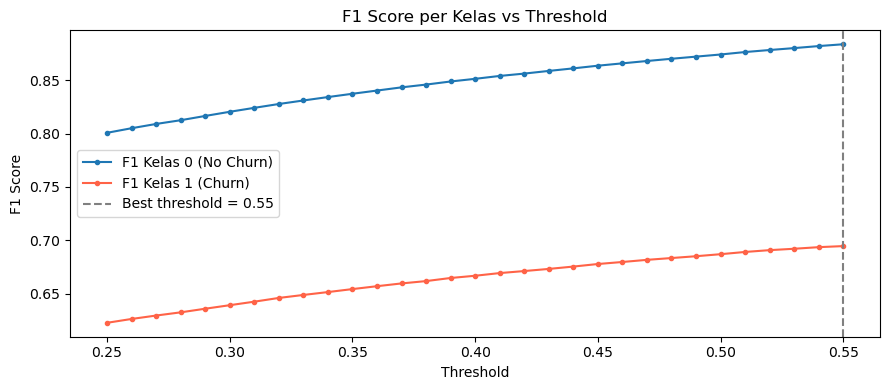

Plot disimpan sebagai threshold_tuning.png


In [104]:
# ─────────────────────────────────────────────
# 8. EVALUASI — THRESHOLD TERBAIK
# ─────────────────────────────────────────────
y_pred_best = (y_prob >= best_threshold).astype(int)
 
print(f"\nHASIL — Threshold Optimized ({best_threshold})")
print("="*55)
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1 Kelas 1: {f1_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best))
 
# ─────────────────────────────────────────────
# 9. PLOT: F1 Score vs Threshold
# ─────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(df_thresh['threshold'], df_thresh['f1_kelas_0'], label='F1 Kelas 0 (No Churn)', marker='o', markersize=3)
plt.plot(df_thresh['threshold'], df_thresh['f1_kelas_1'], label='F1 Kelas 1 (Churn)',    marker='o', markersize=3, color='tomato')
plt.axvline(best_threshold, linestyle='--', color='gray', label=f'Best threshold = {best_threshold}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score per Kelas vs Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150)
plt.show()
print("Plot disimpan sebagai threshold_tuning.png")

## Uji Testing

In [33]:
test = test.drop(['gender'], axis=1)

In [106]:
y_prob_test = xgb.predict_proba(test)[:, 1]

# pakai threshold (bisa kamu ubah)
y_pred_test = (y_prob_test > 0.3).astype(int)

In [112]:
import pandas as pd

submission = pd.DataFrame({
    'id': test['id'],
    'Churn': y_pred_test
})

submission.to_csv('submission2.csv', index=False)

In [114]:
print(submission.head())
print(submission['Churn'].value_counts())

       id  Churn
0  594194      0
1  594195      0
2  594196      0
3  594197      0
4  594198      1
Churn
0    151172
1    103483
Name: count, dtype: int64
